# Compare Wrong Predictions Across Models

This notebook analyzes and compares the wrong predictions from:
- BERT (bert-base-turkish-cased-allnli_tr)
- mDeBERTa (mDeBERTa-v3-base-mnli-xnli)
- Qwen2-7B (Qwen2-7B-Instruct)

We'll analyze:
1. Overlap of mistakes (which examples all models get wrong)
2. Unique mistakes per model

3. Error patterns and confusion matrices comparisonAll outputs will be saved to `comparison_results/` folder.


In [ ]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Create output directory
output_dir = Path("comparison_results")
output_dir.mkdir(exist_ok=True)

print(f"Output directory: {output_dir.absolute()}")plt.rcParams['figure.figsize'] = (12, 6)

sns.set_style("whitegrid")
# Set style

## Load Wrong Predictions

In [ ]:
# Load wrong predictions for each model and split
models = {
    "BERT": "bert-base-turkish-cased-allnli_tr",
    "mDeBERTa": "mDeBERTa-v3-base-mnli-xnli",
    "Qwen2-7B": "Qwen2-7B-Instruct"
}

splits = ["test_matched", "test_mismatched"]

wrong_predictions = {}

for model_name, model_dir in models.items():
    wrong_predictions[model_name] = {}
    for split in splits:
        csv_path = Path(model_dir) / f"wrong_trglue_mnli_{split}.csv"
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            wrong_predictions[model_name][split] = df
            print(f"{model_name} - {split}: {len(df)} wrong predictions")
        else:
            print(f"Warning: {csv_path} not found")
            wrong_predictions[model_name][split] = pd.DataFrame()

BERT - test_matched: 2251 wrong predictions
BERT - test_mismatched: 1720 wrong predictions
mDeBERTa - test_matched: 1832 wrong predictions
mDeBERTa - test_mismatched: 1447 wrong predictions


## Load Metrics for Context

In [3]:
# Load metrics to show accuracy context
metrics = {}
for model_name, model_dir in models.items():
    metrics_path = Path(model_dir) / "metrics.json"
    if metrics_path.exists():
        with open(metrics_path, 'r') as f:
            metrics[model_name] = json.load(f)["trglue_mnli"]

# Display metrics
metrics_df = []
for model_name in models.keys():
    for split in splits:
        if model_name in metrics and split in metrics[model_name]:
            metrics_df.append({
                "Model": model_name,
                "Split": split,
                "Accuracy": f"{metrics[model_name][split]['accuracy']:.4f}",
                "F1 Macro": f"{metrics[model_name][split]['f1_macro']:.4f}"
            })

print("\nModel Performance Overview:")
print(pd.DataFrame(metrics_df).to_string(index=False))


Model Performance Overview:
   Model           Split Accuracy F1 Macro
    BERT    test_matched   0.7501   0.7434
    BERT test_mismatched   0.8134   0.8068
mDeBERTa    test_matched   0.7966   0.7936
mDeBERTa test_mismatched   0.8430   0.8393


## Analyze Overlap of Wrong Predictions

In [ ]:
def analyze_overlap(split_name):
    """
    Analyze which examples are wrong across multiple models.
    """
    print(f"\n{'='*80}")
    print(f"Overlap Analysis for {split_name}")
    print(f"{'='*80}")
    
    # Get indices of wrong predictions for each model
    wrong_indices = {}
    for model_name in models.keys():
        if split_name in wrong_predictions[model_name] and not wrong_predictions[model_name][split_name].empty:
            wrong_indices[model_name] = set(wrong_predictions[model_name][split_name]['index'].values)
    
    # Find intersections
    model_names = list(wrong_indices.keys())
    
    if len(model_names) < 2:
        print("Not enough models with wrong predictions to compare")
        return
    
    # All three models wrong
    if len(model_names) == 3:
        all_three_wrong = wrong_indices['BERT'] & wrong_indices['mDeBERTa'] & wrong_indices['Qwen2-7B']
        print(f"\nExamples wrong by ALL THREE models: {len(all_three_wrong)}")
        
        # Pairs
        bert_mdeberta = (wrong_indices['BERT'] & wrong_indices['mDeBERTa']) - all_three_wrong
        bert_qwen = (wrong_indices['BERT'] & wrong_indices['Qwen2-7B']) - all_three_wrong
        mdeberta_qwen = (wrong_indices['mDeBERTa'] & wrong_indices['Qwen2-7B']) - all_three_wrong
        
        print(f"\nExamples wrong by PAIRS (excluding all three):")
        print(f"  BERT + mDeBERTa only: {len(bert_mdeberta)}")
        print(f"  BERT + Qwen2-7B only: {len(bert_qwen)}")
        print(f"  mDeBERTa + Qwen2-7B only: {len(mdeberta_qwen)}")
        
        # Unique to each model
        bert_only = wrong_indices['BERT'] - wrong_indices['mDeBERTa'] - wrong_indices['Qwen2-7B']
        mdeberta_only = wrong_indices['mDeBERTa'] - wrong_indices['BERT'] - wrong_indices['Qwen2-7B']
        qwen_only = wrong_indices['Qwen2-7B'] - wrong_indices['BERT'] - wrong_indices['mDeBERTa']
        
        print(f"\nExamples wrong by ONLY ONE model:")
        print(f"  BERT only: {len(bert_only)}")
        print(f"  mDeBERTa only: {len(mdeberta_only)}")
        print(f"  Qwen2-7B only: {len(qwen_only)}")
        
        # Create visualization data

        return {    overlap_results[split] = analyze_overlap(split)

            'all_three': len(all_three_wrong),for split in splits:

            'bert_mdeberta': len(bert_mdeberta),overlap_results = {}

            'bert_qwen': len(bert_qwen),# Analyze both splits

            'mdeberta_qwen': len(mdeberta_qwen),

            'bert_only': len(bert_only),        }

            'mdeberta_only': len(mdeberta_only),            'mdeberta_only_indices': mdeberta_only

            'qwen_only': len(qwen_only),            'bert_only_indices': bert_only,

            'all_three_indices': all_three_wrong,            'both_indices': both_wrong,

            'bert_only_indices': bert_only,            'mdeberta_only': len(mdeberta_only),

            'mdeberta_only_indices': mdeberta_only,            'bert_only': len(bert_only),

            'qwen_only_indices': qwen_only            'both': len(both_wrong),

        }        return {

    else:        

        # Fallback for 2 models        print(f"  mDeBERTa only: {len(mdeberta_only)}")

        both_wrong = wrong_indices['BERT'] & wrong_indices['mDeBERTa']        print(f"  BERT only: {len(bert_only)}")

        bert_only = wrong_indices['BERT'] - wrong_indices['mDeBERTa']        print(f"\nExamples wrong by BOTH models: {len(both_wrong)}")

        mdeberta_only = wrong_indices['mDeBERTa'] - wrong_indices['BERT']        


Overlap Analysis for test_matched

Examples wrong by BOTH models: 1388

Examples wrong by ONLY ONE model:
  BERT only: 863
  mDeBERTa only: 444

Overlap Analysis for test_mismatched

Examples wrong by BOTH models: 1008

Examples wrong by ONLY ONE model:
  BERT only: 712
  mDeBERTa only: 439


## Visualize Overlap

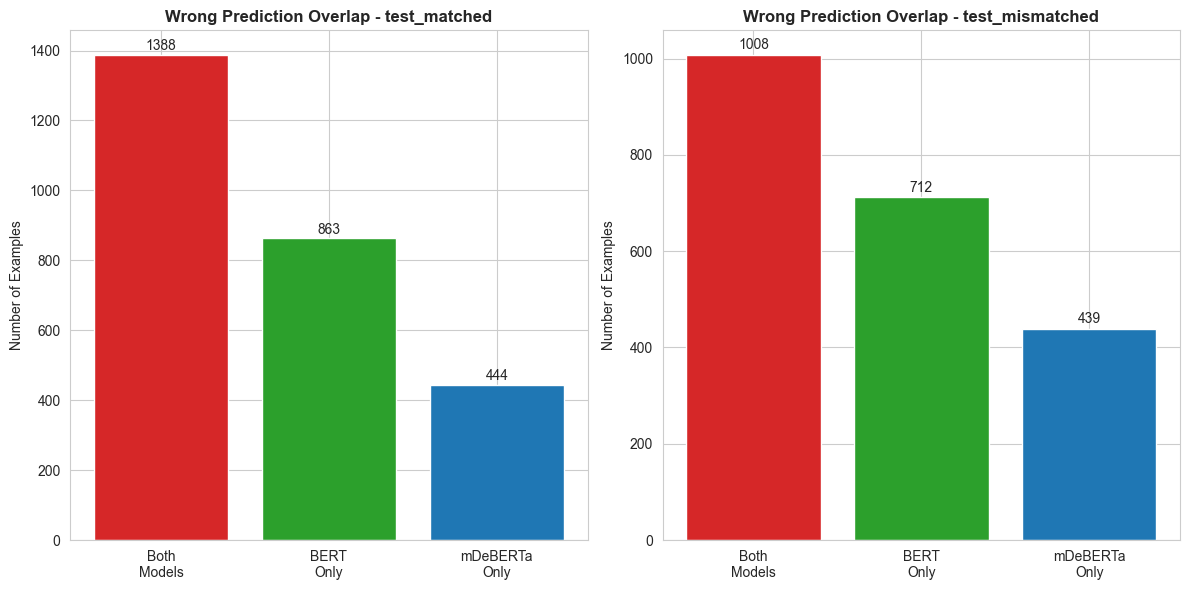


Visualization saved to wrong_predictions_overlap.png


In [ ]:
# Create stacked bar chart for overlap
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, split in enumerate(splits):
    if overlap_results[split] is None:
        continue
        
    data = overlap_results[split]
    
    # Check if we have 3 models or 2
    if 'all_three' in data:
        categories = ['All 3', 'BERT+\nmDeBERTa', 'BERT+\nQwen', 'mDeBERTa+\nQwen', 'BERT\nOnly', 'mDeBERTa\nOnly', 'Qwen\nOnly']
        values = [
            data['all_three'],
            data['bert_mdeberta'],
            data['bert_qwen'],
            data['mdeberta_qwen'],
            data['bert_only'],
            data['mdeberta_only'],
            data['qwen_only']
        ]
        colors = ['#d62728', '#ff7f0e', '#ff9896', '#ffbb78', '#2ca02c', '#98df8a', '#9467bd']
    else:
        categories = ['Both\nModels', 'BERT\nOnly', 'mDeBERTa\nOnly']
        values = [
            data['both'],
            data['bert_only'],
            data['mdeberta_only']
        ]
        colors = ['#d62728', '#2ca02c', '#1f77b4']
    
    axes[idx].bar(categories, values, color=colors)
    axes[idx].set_title(f'Wrong Prediction Overlap - {split}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Number of Examples')
    axes[idx].tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for i, v in enumerate(values):
        axes[idx].text(i, v + 5, str(v), ha='center', va='bottom')

plt.tight_layout()
output_path = output_dir / 'wrong_predictions_overlap.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to {output_path}")

## Analyze Error Patterns by True/Predicted Label

In [6]:
def analyze_error_patterns(split_name):
    """
    Analyze what types of errors each model makes.
    """
    print(f"\n{'='*80}")
    print(f"Error Pattern Analysis for {split_name}")
    print(f"{'='*80}")
    
    for model_name in models.keys():
        if split_name not in wrong_predictions[model_name] or wrong_predictions[model_name][split_name].empty:
            continue
            
        df = wrong_predictions[model_name][split_name]
        
        print(f"\n{model_name}:")
        print("-" * 40)
        
        # Count error types (true_label -> predicted_label)
        error_types = df.groupby(['true_label', 'predicted_label']).size().reset_index(name='count')
        error_types = error_types.sort_values('count', ascending=False)
        
        print("\nMost common error types:")
        for _, row in error_types.iterrows():
            print(f"  {row['true_label']:>13} → {row['predicted_label']:<13}: {row['count']:>3} errors")

for split in splits:
    analyze_error_patterns(split)


Error Pattern Analysis for test_matched

BERT:
----------------------------------------

Most common error types:
        neutral → contradiction: 1040 errors
        neutral → entailment   : 432 errors
  contradiction → entailment   : 412 errors
     entailment → neutral      : 167 errors
  contradiction → neutral      : 121 errors
     entailment → contradiction:  79 errors

mDeBERTa:
----------------------------------------

Most common error types:
        neutral → contradiction: 588 errors
        neutral → entailment   : 562 errors
  contradiction → entailment   : 486 errors
     entailment → neutral      :  99 errors
  contradiction → neutral      :  66 errors
     entailment → contradiction:  31 errors

Error Pattern Analysis for test_mismatched

BERT:
----------------------------------------

Most common error types:
        neutral → contradiction: 912 errors
        neutral → entailment   : 290 errors
  contradiction → entailment   : 208 errors
     entailment → neutral   

## Sample Hard Examples (Wrong by All Models)

In [ ]:
def show_hard_examples(split_name, n=5):
    """
    Show examples that multiple models got wrong.
    """
    print(f"\n{'='*80}")
    print(f"Hard Examples - {split_name}")
    print(f"{'='*80}")
    
    if overlap_results[split_name] is None:
        print("No overlap data available")
        return
    
    # Check if we have 3 models or 2
    if 'all_three_indices' in overlap_results[split_name]:
        if len(overlap_results[split_name]['all_three_indices']) == 0:
            print("No examples wrong by all three models")
            return
        indices = list(overlap_results[split_name]['all_three_indices'])[:n]
        title = "Examples wrong by ALL THREE models"
    else:
        if len(overlap_results[split_name]['both_indices']) == 0:
            print("No examples wrong by both models")
            return
        indices = list(overlap_results[split_name]['both_indices'])[:n]
        title = "Examples wrong by BOTH models"
    
    print(f"\n{title}:")
    
    # Get examples from BERT dataframe (they should be the same across models)
    bert_wrongs = wrong_predictions['BERT'][split_name]
    
    for idx in indices:
        example = bert_wrongs[bert_wrongs['index'] == idx].iloc[0]
        
        print(f"\nExample {idx}:")
        print("-" * 80)
        print(f"Premise: {example['premise']}")
        print(f"Hypothesis: {example['hypothesis']}")
        print(f"True Label: {example['true_label']}")
        
        # Show what each model predicted
        print(f"\nPredictions:")
        for model_name in models.keys():
            model_example = wrong_predictions[model_name][split_name]
            model_example = model_example[model_example['index'] == idx]
            if not model_example.empty:
                pred = model_example.iloc[0]['predicted_label']
                print(f"  {model_name:>10}: {pred}")

for split in splits:
    show_hard_examples(split, n=3)


Hard Examples (Wrong by Both Models) - test_matched

Example 1:
--------------------------------------------------------------------------------
Premise: Savcının fitne - fesat içinde olduğunu söylemek için mangal gibi yürek lazım.
Hypothesis: Savcının fitne fesat içinde olduğu iddia edilebilir.
True Label: neutral

Predictions:
        BERT: entailment
    mDeBERTa: entailment

Example 2:
--------------------------------------------------------------------------------
Premise: Tatil döneminde arkada bırakılan evleri hırsızlardan korumak ve olası hırsızlık girişimine engel olmak için en caydırıcı yöntem elektronik güvenlik sistemi kullanmaktır.
Hypothesis: Tatil sırasında evleri korumak için en etkili yöntem, elektronik güvenlik sistemidir.
True Label: contradiction

Predictions:
        BERT: entailment
    mDeBERTa: entailment

Example 3:
--------------------------------------------------------------------------------
Premise: İfadeler: Otomatik Mandalina, WronzG ve Ehweniscer sapha

## Sample Unique Mistakes per Model

In [ ]:
def show_unique_mistakes(split_name, model_name, n=3):
    """
    Show examples that only one specific model got wrong.
    """
    print(f"\n{'='*80}")
    print(f"Unique Mistakes for {model_name} - {split_name}")
    print(f"{'='*80}")
    
    if overlap_results[split_name] is None:
        return
    
    # Get unique indices for this model
    if model_name == 'BERT':
        unique_indices = list(overlap_results[split_name]['bert_only_indices'])[:n]
    elif model_name == 'mDeBERTa':
        unique_indices = list(overlap_results[split_name]['mdeberta_only_indices'])[:n]
    elif model_name == 'Qwen2-7B' and 'qwen_only_indices' in overlap_results[split_name]:
        unique_indices = list(overlap_results[split_name]['qwen_only_indices'])[:n]
    else:
        unique_indices = []
    
    if len(unique_indices) == 0:
        print(f"No unique mistakes for {model_name}")
        return
    
    model_wrongs = wrong_predictions[model_name][split_name]
    
    for idx in unique_indices:
        example = model_wrongs[model_wrongs['index'] == idx].iloc[0]
        
        print(f"\nExample {idx}:")
        print("-" * 80)
        print(f"Premise: {example['premise']}")
        print(f"Hypothesis: {example['hypothesis']}")
        print(f"True Label: {example['true_label']}")
        print(f"{model_name} Predicted: {example['predicted_label']}")

# Show unique mistakes for test_matched
for model_name in models.keys():
    show_unique_mistakes('test_matched', model_name, n=2)


Unique Mistakes for BERT - test_matched

Example 6146:
--------------------------------------------------------------------------------
Premise: Ayrıca bir tatlı kaşığı bile çamaşır suyu kullanamıyorum.
Hypothesis: I can't even use a teaspoon of bleach.
True Label: neutral
BERT Predicted: contradiction

Example 8195:
--------------------------------------------------------------------------------
Premise: Gün geçmiyor ki elde kalmış bu son eşsiz cennet Çeşme Yarımada'ya bir saldırı olmasın.
Hypothesis: Çeşme Yarımada'ya yönelik saldırılar sürekli olmaktadır
True Label: entailment
BERT Predicted: neutral

Unique Mistakes for mDeBERTa - test_matched

Example 8193:
--------------------------------------------------------------------------------
Premise: CHP'nin açılımlara ihtiyacı var ama bence bu seçimden sonra daha çok müzakere edilebilir.
Hypothesis: Bu ifadede CHP dışında başka konulara dair bilgi verilmemiştir.
True Label: neutral
mDeBERTa Predicted: contradiction

Example 2049:
---

## Summary Statistics

In [ ]:
# Create comprehensive summary
summary_data = []

for split in splits:
    for model_name in models.keys():
        if split in wrong_predictions[model_name] and not wrong_predictions[model_name][split].empty:
            total_wrong = len(wrong_predictions[model_name][split])
            
            # Get unique mistakes count
            if overlap_results[split] is not None:
                if model_name == 'BERT':
                    unique = len(overlap_results[split]['bert_only_indices'])
                elif model_name == 'mDeBERTa':
                    unique = len(overlap_results[split]['mdeberta_only_indices'])
                elif model_name == 'Qwen2-7B' and 'qwen_only_indices' in overlap_results[split]:
                    unique = len(overlap_results[split]['qwen_only_indices'])
                else:
                    unique = 0
                
                unique_pct = (unique / total_wrong * 100) if total_wrong > 0 else 0
            else:
                unique = 0
                unique_pct = 0
            
            summary_data.append({
                'Model': model_name,
                'Split': split,
                'Total Wrong': total_wrong,
                'Unique Wrong': unique,
                'Unique %': f"{unique_pct:.1f}%"
            })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("SUMMARY: Wrong Predictions Overview")
output_path = output_dir / 'wrong_predictions_summary.csv'
summary_df.to_csv(output_path, index=False)

print(f"\nSummary saved to {output_path}")
print("\nSummary saved to wrong_predictions_summary.csv")

# Save to CSVsummary_df.to_csv('wrong_predictions_summary.csv', index=False)


SUMMARY: Wrong Predictions Overview
   Model           Split  Total Wrong  Unique Wrong Unique %
    BERT    test_matched         2251           863    38.3%
mDeBERTa    test_matched         1832           444    24.2%
    BERT test_mismatched         1720           712    41.4%
mDeBERTa test_mismatched         1447           439    30.3%

Summary saved to wrong_predictions_summary.csv


## Export Combined Wrong Predictions

Create a combined dataset with all wrong predictions and model agreement information.

In [ ]:
for split in splits:
    combined_data = []
    
    # Collect all unique indices
    all_indices = set()
    for model_name in models.keys():
        if split in wrong_predictions[model_name] and not wrong_predictions[model_name][split].empty:
            all_indices.update(wrong_predictions[model_name][split]['index'].values)
    
    # For each index, record which models got it wrong
    for idx in sorted(all_indices):
        # Get example info from first available model
        example_info = None
        for model_name in models.keys():
            if split in wrong_predictions[model_name] and not wrong_predictions[model_name][split].empty:
                model_df = wrong_predictions[model_name][split]
                if idx in model_df['index'].values:
                    example_info = model_df[model_df['index'] == idx].iloc[0]
                    break
        
        if example_info is None:
            continue
        
        # Check which models got it wrong
        wrong_by = []
        predictions = {}
        
        for model_name in models.keys():
            if split in wrong_predictions[model_name] and not wrong_predictions[model_name][split].empty:
                model_df = wrong_predictions[model_name][split]
                if idx in model_df['index'].values:
                    wrong_by.append(model_name)
                    predictions[f"{model_name}_pred"] = model_df[model_df['index'] == idx].iloc[0]['predicted_label']
                else:
                    predictions[f"{model_name}_pred"] = "correct"
            else:
                predictions[f"{model_name}_pred"] = "N/A"
        
        combined_data.append({
            'index': idx,
            'premise': example_info['premise'],
            'hypothesis': example_info['hypothesis'],
            'true_label': example_info['true_label'],
            'num_models_wrong': len(wrong_by),
            'models_wrong': ', '.join(wrong_by),
            **predictions
        })
    
    # Save combined dataset
    combined_df = pd.DataFrame(combined_data)
    combined_df = combined_df.sort_values('num_models_wrong', ascending=False)
    
    output_path = output_dir / f'combined_wrong_predictions_{split}.csv'
    combined_df.to_csv(output_path, index=False)
    print(f"\nSaved combined wrong predictions to {output_path}")
    print(f"  Total unique wrong examples: {len(combined_df)}")
    
    # Count by number of models wrong
    for num_wrong in sorted(combined_df['num_models_wrong'].unique(), reverse=True):
        count = len(combined_df[combined_df['num_models_wrong'] == num_wrong])
        print(f"  Wrong by {num_wrong} model(s): {count}")


Saved combined wrong predictions to combined_wrong_predictions_test_matched.csv
  Total unique wrong examples: 2695
  Wrong by both models: 1388
  Wrong by 1 model: 1307

Saved combined wrong predictions to combined_wrong_predictions_test_mismatched.csv
  Total unique wrong examples: 2159
  Wrong by both models: 1008
  Wrong by 1 model: 1151
